# Classification Models: Naive Bayes & Random Forest

**Dataset:** Loan Approval (5000 records)  
**Target:** `approved` (1 = approved, 0 = rejected)  
**Features:** age, income, loan_amount, credit_score, employment_years, num_existing_loans, loan_purpose, property_area

In [1]:
import pandas as pd

df = pd.read_csv("data/loan_data.csv")
df.head()

,age,income,loan_amount,credit_score,employment_years,num_existing_loans,loan_purpose,property_area,approved
0,59,77767,133041,482,5,1,education,rural,0
1,49,48054,58019,564,15,0,car,urban,0
2,35,95319,212226,387,1,4,car,urban,0
3,63,122789,238169,761,0,2,business,semi_urban,1
4,28,65397,12373,345,29,6,education,urban,0


In [2]:
df.shape

(5000, 9)

In [3]:
df.dtypes

age                    int64
income                 int64
loan_amount            int64
credit_score           int64
employment_years       int64
num_existing_loans     int64
loan_purpose          object
property_area         object
approved               int64
dtype: object

In [4]:
## check na and null values

print(df.isna().sum())
print(df.isnull().sum())

age                   0
income                0
loan_amount           0
credit_score          0
employment_years      0
num_existing_loans    0
loan_purpose          0
property_area         0
approved              0
dtype: int64
age                   0
income                0
loan_amount           0
credit_score          0
employment_years      0
num_existing_loans    0
loan_purpose          0
property_area         0
approved              0
dtype: int64


In [5]:
df.describe()

,age,income,loan_amount,credit_score,employment_years,num_existing_loans,approved
count,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,42.575000,84685.34900,253200.587000,571.732200,16.951400,3.569800,0.458400
std,12.554597,37678.43216,141082.807386,159.542709,10.068233,2.260564,0.498316
min,21.000000,20028.00000,5036.000000,300.000000,0.000000,0.000000,0.000000
25%,32.000000,51402.00000,131582.750000,433.000000,8.000000,2.000000,0.000000
50%,43.000000,85484.50000,255394.500000,570.000000,17.000000,4.000000,0.000000
75%,53.000000,117660.00000,372744.250000,707.250000,26.000000,6.000000,1.000000
max,64.000000,149949.00000,499735.000000,849.000000,34.000000,7.000000,1.000000


In [6]:
df.approved.value_counts()

approved
0    2708
1    2292
Name: count, dtype: int64

## Handle Categorical Variables

In [7]:
df.loan_purpose.unique()

array(['education', 'car', 'business', 'home', 'personal'], dtype=object)

In [8]:
df.property_area.unique()

array(['rural', 'urban', 'semi_urban'], dtype=object)

In [9]:
purpose_dummies = pd.get_dummies(df.loan_purpose)
purpose_dummies.head()

,business,car,education,home,personal
0,False,False,True,False,False
1,False,True,False,False,False
2,False,True,False,False,False
3,True,False,False,False,False
4,False,False,True,False,False


In [10]:
area_dummies = pd.get_dummies(df.property_area)
area_dummies.head()

,rural,semi_urban,urban
0,True,False,False
1,False,False,True
2,False,False,True
3,False,True,False
4,False,False,True


In [11]:
df = pd.concat([df, purpose_dummies, area_dummies], axis="columns")
df.head()

,age,income,loan_amount,credit_score,employment_years,num_existing_loans,loan_purpose,property_area,approved,business,car,education,home,personal,rural,semi_urban,urban
0,59,77767,133041,482,5,1,education,rural,0,False,False,True,False,False,True,False,False
1,49,48054,58019,564,15,0,car,urban,0,False,True,False,False,False,False,False,True
2,35,95319,212226,387,1,4,car,urban,0,False,True,False,False,False,False,False,True
3,63,122789,238169,761,0,2,business,semi_urban,1,True,False,False,False,False,False,True,False
4,28,65397,12373,345,29,6,education,urban,0,False,False,True,False,False,False,False,True


In [12]:
df.drop(["loan_purpose", "property_area", "personal", "urban"], axis="columns", inplace=True)
df.head()

,age,income,loan_amount,credit_score,employment_years,num_existing_loans,approved,business,car,education,home,rural,semi_urban
0,59,77767,133041,482,5,1,0,False,False,True,False,True,False
1,49,48054,58019,564,15,0,0,False,True,False,False,False,False
2,35,95319,212226,387,1,4,0,False,True,False,False,False,False
3,63,122789,238169,761,0,2,1,True,False,False,False,False,True
4,28,65397,12373,345,29,6,0,False,False,True,False,False,False


In [13]:
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)
df.head()

,age,income,loan_amount,credit_score,employment_years,num_existing_loans,approved,business,car,education,home,rural,semi_urban
0,59,77767,133041,482,5,1,0,0,0,1,0,1,0
1,49,48054,58019,564,15,0,0,0,1,0,0,0,0
2,35,95319,212226,387,1,4,0,0,1,0,0,0,0
3,63,122789,238169,761,0,2,1,1,0,0,0,0,1
4,28,65397,12373,345,29,6,0,0,0,1,0,0,0


## Visualize Data

Text(0, 0.5, 'Approved')

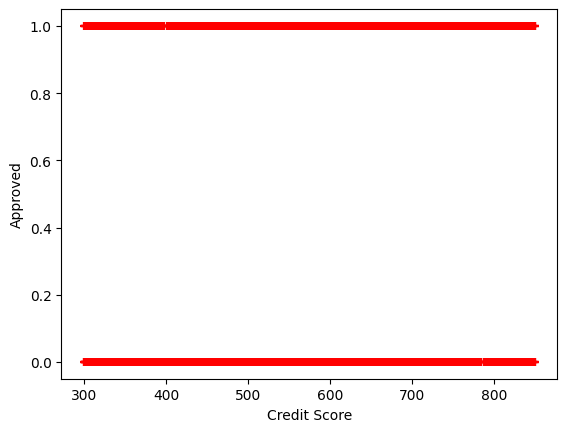

In [14]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.scatter(df.credit_score, df.approved, marker="+", color="red")
plt.xlabel("Credit Score")
plt.ylabel("Approved")

Text(0, 0.5, 'Approved')

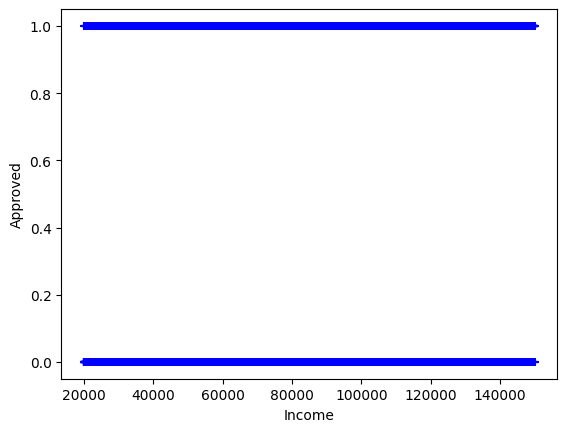

In [15]:
plt.scatter(df.income, df.approved, marker="+", color="blue")
plt.xlabel("Income")
plt.ylabel("Approved")

## Prepare Features and Target

In [16]:
x = df.drop("approved", axis="columns")
x.head()

,age,income,loan_amount,credit_score,employment_years,num_existing_loans,business,car,education,home,rural,semi_urban
0,59,77767,133041,482,5,1,0,0,1,0,1,0
1,49,48054,58019,564,15,0,0,1,0,0,0,0
2,35,95319,212226,387,1,4,0,1,0,0,0,0
3,63,122789,238169,761,0,2,1,0,0,0,0,1
4,28,65397,12373,345,29,6,0,0,1,0,0,0


In [17]:
y = df.approved

In [18]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

---
## Model 1: Naive Bayes (GaussianNB)

In [19]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(x_train, y_train)

,priors,None
,var_smoothing,1e-09


In [20]:
nb_model.predict(x_test)

array([1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,

In [21]:
nb_model.score(x_test, y_test)

0.673

In [22]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_nb = nb_model.predict(x_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Confusion Matrix:
[[399 124]
 [203 274]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.76      0.71       523
           1       0.69      0.57      0.63       477

    accuracy                           0.67      1000
   macro avg       0.68      0.67      0.67      1000
weighted avg       0.68      0.67      0.67      1000



---
## Model 2: Random Forest

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
rf_model.predict(x_test)

array([1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0,

In [25]:
rf_model.score(x_test, y_test)

0.652

In [26]:
y_pred_rf = rf_model.predict(x_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Confusion Matrix:
[[382 141]
 [207 270]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.73      0.69       523
           1       0.66      0.57      0.61       477

    accuracy                           0.65      1000
   macro avg       0.65      0.65      0.65      1000
weighted avg       0.65      0.65      0.65      1000



## Feature Importance (Random Forest)

Text(0, 0.5, 'Importance')

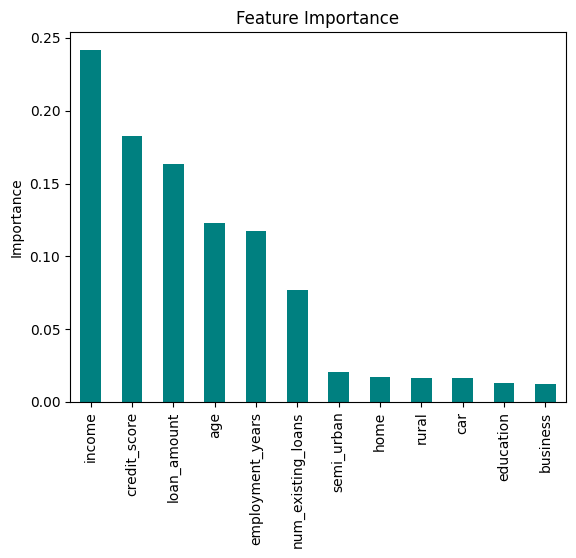

In [27]:
feat_imp = pd.Series(rf_model.feature_importances_, index=x.columns).sort_values(ascending=False)
feat_imp.plot(kind="bar", color="teal")
plt.title("Feature Importance")
plt.ylabel("Importance")

---
## Compare Models

In [28]:
print(f"Naive Bayes Score:   {nb_model.score(x_test, y_test):.4f}")
print(f"Random Forest Score: {rf_model.score(x_test, y_test):.4f}")

Naive Bayes Score:   0.6730
Random Forest Score: 0.6520


---
---

# Use Case 2: IT Support Ticket Classification

**Scenario:** In IT services, support tickets are created and land in a Service Desk queue. The Service Desk team reads the ticket summary and description, then routes it to the appropriate application/team queue.

**Goal:** Automate this routing using text classification — given a ticket's summary and description, predict the correct queue.

**Dataset:** `data/support_tickets.csv` (5000 tickets)  
**Target:** `assigned_queue` (Network Team, Database Team, Application Team, Infrastructure Team, Security Team)  
**Features:** `summary` and `description` (free-form text) + `priority`

In [29]:
tickets_df = pd.read_csv("data/support_tickets.csv")
tickets_df.head()

,ticket_id,summary,description,priority,assigned_queue
0,INC11502,Help needed - Database replication lag is incr...,Stored procedure sp_calculate_commission is re...,Medium,Database Team
1,INC12587,URGENT: Error 500 on checkout page,Checkout page returning HTTP 500 when users ap...,High,Application Team
2,INC12654,Batch job stuck in running state - please help,Nightly batch job for invoice generation has b...,High,Application Team
3,INC11056,Issue: Need database user created for new appl...,Data migration from Oracle to PostgreSQL faili...,High,Database Team
4,INC10706,Request: VPN connection dropping frequently - ...,Getting disconnected from VPN every 10 minutes...,Critical,Network Team


In [30]:
tickets_df.shape

(5000, 5)

In [31]:
## check na and null values

print(tickets_df.isna().sum())
print(tickets_df.isnull().sum())

ticket_id         0
summary           0
description       0
priority          0
assigned_queue    0
dtype: int64
ticket_id         0
summary           0
description       0
priority          0
assigned_queue    0
dtype: int64


In [32]:
tickets_df.assigned_queue.value_counts()

assigned_queue
Database Team          1000
Application Team       1000
Network Team           1000
Infrastructure Team    1000
Security Team          1000
Name: count, dtype: int64

In [33]:
tickets_df.priority.value_counts()

priority
Medium      1933
High        1561
Low          988
Critical     518
Name: count, dtype: int64

## Text Feature Engineering

Combine `summary` and `description` into a single text column, then convert text to numerical features using **TF-IDF** (Term Frequency - Inverse Document Frequency).

TF-IDF converts text into a matrix of numbers where each word gets a score based on how important it is in a document relative to the entire corpus.

In [34]:
tickets_df["text"] = tickets_df["summary"] + " " + tickets_df["description"]
tickets_df[["text", "assigned_queue"]].head()

,text,assigned_queue
0,Help needed - Database replication lag is incr...,Database Team
1,URGENT: Error 500 on checkout page Checkout pa...,Application Team
2,Batch job stuck in running state - please help...,Application Team
3,Issue: Need database user created for new appl...,Database Team
4,Request: VPN connection dropping frequently - ...,Network Team


In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
x_tfidf = tfidf.fit_transform(tickets_df["text"])

print(f"TF-IDF matrix shape: {x_tfidf.shape}")
print(f"Sample feature names: {tfidf.get_feature_names_out()[:20]}")

TF-IDF matrix shape: (5000, 697)
Sample feature names: ['01' '02' '042' '10' '100' '1000' '101' '12' '14' '15' '17' '185' '19502'
 '200' '200ms' '220' '23' '24' '256' '2fa']


In [36]:
y_tickets = tickets_df["assigned_queue"]

from sklearn.model_selection import train_test_split

x_train_t, x_test_t, y_train_t, y_test_t = train_test_split(x_tfidf, y_tickets, test_size=0.2, random_state=42)

---
## Model 1: Multinomial Naive Bayes

MultinomialNB is the go-to Naive Bayes variant for text classification. It works with TF-IDF/count features and assumes word frequencies follow a multinomial distribution.

In [37]:
from sklearn.naive_bayes import MultinomialNB

nb_ticket_model = MultinomialNB()
nb_ticket_model.fit(x_train_t, y_train_t)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [38]:
nb_ticket_model.predict(x_test_t)

array(['Application Team', 'Database Team', 'Network Team',
       'Application Team', 'Security Team', 'Network Team',
       'Security Team', 'Infrastructure Team', 'Application Team',
       'Security Team', 'Network Team', 'Network Team',
       'Application Team', 'Security Team', 'Application Team',
       'Database Team', 'Network Team', 'Infrastructure Team',
       'Database Team', 'Infrastructure Team', 'Infrastructure Team',
       'Application Team', 'Security Team', 'Application Team',
       'Infrastructure Team', 'Infrastructure Team', 'Security Team',
       'Database Team', 'Network Team', 'Network Team', 'Database Team',
       'Network Team', 'Infrastructure Team', 'Database Team',
       'Network Team', 'Application Team', 'Security Team',
       'Application Team', 'Infrastructure Team', 'Database Team',
       'Infrastructure Team', 'Network Team', 'Network Team',
       'Application Team', 'Application Team', 'Security Team',
       'Database Team', 'Network Team

In [39]:
nb_ticket_model.score(x_test_t, y_test_t)

1.0

In [40]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_nb_t = nb_ticket_model.predict(x_test_t)
print("Confusion Matrix:")
print(confusion_matrix(y_test_t, y_pred_nb_t))
print("\nClassification Report:")
print(classification_report(y_test_t, y_pred_nb_t))

Confusion Matrix:
[[192   0   0   0   0]
 [  0 214   0   0   0]
 [  0   0 208   0   0]
 [  0   0   0 178   0]
 [  0   0   0   0 208]]

Classification Report:
                     precision    recall  f1-score   support

   Application Team       1.00      1.00      1.00       192
      Database Team       1.00      1.00      1.00       214
Infrastructure Team       1.00      1.00      1.00       208
       Network Team       1.00      1.00      1.00       178
      Security Team       1.00      1.00      1.00       208

           accuracy                           1.00      1000
          macro avg       1.00      1.00      1.00      1000
       weighted avg       1.00      1.00      1.00      1000



---
## Model 2: Random Forest (on TF-IDF features)

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf_ticket_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_ticket_model.fit(x_train_t, y_train_t)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
rf_ticket_model.predict(x_test_t)

array(['Application Team', 'Database Team', 'Network Team',
       'Application Team', 'Security Team', 'Network Team',
       'Security Team', 'Infrastructure Team', 'Application Team',
       'Security Team', 'Network Team', 'Network Team',
       'Application Team', 'Security Team', 'Application Team',
       'Database Team', 'Network Team', 'Infrastructure Team',
       'Database Team', 'Infrastructure Team', 'Infrastructure Team',
       'Application Team', 'Security Team', 'Application Team',
       'Infrastructure Team', 'Infrastructure Team', 'Security Team',
       'Database Team', 'Network Team', 'Network Team', 'Database Team',
       'Network Team', 'Infrastructure Team', 'Database Team',
       'Network Team', 'Application Team', 'Security Team',
       'Application Team', 'Infrastructure Team', 'Database Team',
       'Infrastructure Team', 'Network Team', 'Network Team',
       'Application Team', 'Application Team', 'Security Team',
       'Database Team', 'Network Team

In [43]:
rf_ticket_model.score(x_test_t, y_test_t)

1.0

In [44]:
y_pred_rf_t = rf_ticket_model.predict(x_test_t)
print("Confusion Matrix:")
print(confusion_matrix(y_test_t, y_pred_rf_t))
print("\nClassification Report:")
print(classification_report(y_test_t, y_pred_rf_t))

Confusion Matrix:
[[192   0   0   0   0]
 [  0 214   0   0   0]
 [  0   0 208   0   0]
 [  0   0   0 178   0]
 [  0   0   0   0 208]]

Classification Report:
                     precision    recall  f1-score   support

   Application Team       1.00      1.00      1.00       192
      Database Team       1.00      1.00      1.00       214
Infrastructure Team       1.00      1.00      1.00       208
       Network Team       1.00      1.00      1.00       178
      Security Team       1.00      1.00      1.00       208

           accuracy                           1.00      1000
          macro avg       1.00      1.00      1.00      1000
       weighted avg       1.00      1.00      1.00      1000



## Top Words per Queue (from Naive Bayes)

In [45]:
feature_names = tfidf.get_feature_names_out()

for i, queue in enumerate(nb_ticket_model.classes_):
    top_indices = nb_ticket_model.feature_log_prob_[i].argsort()[-10:][::-1]
    top_words = [feature_names[j] for j in top_indices]
    print(f"{queue}: {', '.join(top_words)}")

Application Team: users, page, logs, returning, generation, api, application, session, upload, screen
Database Team: table, database, percent, running, query, collection, sales, need, schema, backup
Infrastructure Team: server, kernel, gb, cpu, alerts, container, web, bucket, storage, production
Network Team: network, vpn, firewall, dns, drops, multiple, traffic, help, port, high
Security Team: access, need, admin, employee, account, detected, portal, completed, login, data


---
## Compare Ticket Classification Models

In [46]:
print(f"Naive Bayes (MultinomialNB) Score: {nb_ticket_model.score(x_test_t, y_test_t):.4f}")
print(f"Random Forest Score:               {rf_ticket_model.score(x_test_t, y_test_t):.4f}")

Naive Bayes (MultinomialNB) Score: 1.0000
Random Forest Score:               1.0000


## Try It: Predict Queue for a New Ticket

In [60]:
sample_ticket = ["query is long running in database"]
sample_tfidf = tfidf.transform(sample_ticket)

print(f"Naive Bayes prediction:   {nb_ticket_model.predict(sample_tfidf)[0]}")
print(f"Random Forest prediction: {rf_ticket_model.predict(sample_tfidf)[0]}")

Naive Bayes prediction:   Database Team
Random Forest prediction: Database Team


In [64]:
sample_ticket_2 = ["Production CPU at 100 percent. Slow queries blocking the order processing."]
sample_tfidf_2 = tfidf.transform(sample_ticket_2)

print(f"Naive Bayes prediction:   {nb_ticket_model.predict(sample_tfidf_2)[0]}")
print(f"Random Forest prediction: {rf_ticket_model.predict(sample_tfidf_2)[0]}")

Naive Bayes prediction:   Database Team
Random Forest prediction: Application Team


In [ ]:
sample_ticket_3 = ["Suspicious login attempts from unknown IP on admin portal. Possible brute force attack detected."]
sample_tfidf_3 = tfidf.transform(sample_ticket_3)

print(f"Naive Bayes prediction:   {nb_ticket_model.predict(sample_tfidf_3)[0]}")
print(f"Random Forest prediction: {rf_ticket_model.predict(sample_tfidf_3)[0]}")

TF-IDF Vectorization Explained
TF-IDF stands for Term Frequency - Inverse Document Frequency. It converts text into numbers in two steps:

TF (Term Frequency) — How often a word appears in this document.

If "VPN" appears 3 times in a 50-word ticket, TF = 3/50 = 0.06
IDF (Inverse Document Frequency) — How rare a word is across all documents.

If "the" appears in 4900 out of 5000 tickets, IDF is very low (common word, not useful)
If "deadlock" appears in only 50 tickets, IDF is high (rare word, very useful for classification)
TF-IDF = TF × IDF — Words that are frequent in a specific ticket but rare overall get the highest scores. This is why it works well: "VPN" scores high in network tickets but low overall, making it a strong signal.

Limitations of TF-IDF
No word order — "server crashed the application" and "application crashed the server" produce the same vector
No meaning — "VPN" and "virtual private network" are treated as completely unrelated words
Sparse, high-dimensional — With 5000 features, most values are zero. Doesn't scale well to large vocabularies
No context — "bank" (riverbank vs financial bank) always gets the same representation


Better Alternatives for Production
Approach	How It Works	When to Use
Word2Vec / GloVe : Pre-trained word embeddings that map words to dense 100-300 dimensional vectors. "VPN" and "network" end up close together in vector space. Average word vectors for a document.	Medium-scale, when you need semantic similarity but don't have GPU resources

Sentence Transformers (SBERT) : Produces a single dense vector (384-768 dims) for an entire sentence/paragraph. Understands context and word order. Models like all-MiniLM-L6-v2 are fast.	Best balance of quality and speed for production ticket classification

Large Language Model embeddings	: Models like OpenAI text-embedding-3-small or open-source alternatives generate rich embeddings from full text. Understand nuance, context, synonyms.	When accuracy is critical and you have API budget or GPU

Fine-tuned BERT/RoBERTa	: Take a pre-trained transformer, add a classification head, and fine-tune on your labeled tickets. The model learns task-specific representations.	When you have enough labeled data (1000+) and need the highest accuracy

Typical Production Architecture for Ticket Routing

Ticket Created
    │
    ▼
Text → Sentence Transformer → Dense Vector (384 dims)
    │
    ▼
Classifier (fine-tuned or even simple logistic regression on embeddings)
    │
    ▼
Predicted Queue + Confidence Score
    │
    ▼
If confidence > 0.85 → auto-route
If confidence < 0.85 → send to Service Desk for manual review
Quick Comparison
Method	Understands Meaning	Handles Synonyms	Speed	Accuracy
TF-IDF	No	No	Very fast	Good for practice
Word2Vec/GloVe	Partially	Yes	Fast	Better
Sentence Transformers	Yes	Yes	Medium	Very good
Fine-tuned BERT	Yes	Yes	Slower	Best
